#Бельдинова Мария
#6133 - 010402D

In [1]:
!pip uninstall numba -y
!pip install numba==0.59.0

import numpy as np
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
from numba import cuda

# Проверка GPU
print("CUDA доступна:", cuda.is_available())
if cuda.is_available():
    print("GPU:", cuda.get_current_device())

Found existing installation: numba 0.59.0
Uninstalling numba-0.59.0:
  Successfully uninstalled numba-0.59.0
  Using cached numba-0.59.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.7 kB)
Using cached numba-0.59.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.59.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.59.0 which is incompatible.
numba-cuda 0.22.2 requires numba>=0.60.0, but you have numba 0.59.0 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
CUDA доступна: True
GPU: <CUDA device 0 'Tesla T4'>


In [2]:
import numpy as np
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
from numba import cuda

# Функция для CPU: последовательное суммирование

In [3]:
def sum_vector_cpu(vec):
    """
    Вычисляет сумму элементов вектора на CPU.

    Параметры:
    vec (np.ndarray): Входной вектор.

    Возвращает:
    tuple: (сумма, время выполнения в секундах)
    """
    start_time = time.time()

    total = 0.0
    for x in vec:
        total += x

    end_time = time.time()
    return total, end_time - start_time

# Ядро CUDA для суммирования (каждый поток суммирует один блок)

In [4]:
@cuda.jit
def sum_kernel(vec, result):
    """
    Ядро: каждый поток суммирует часть вектора,
    затем делаем редукцию внутри блока.
    """
    # Разделяем вектор на блоки
    tid = cuda.threadIdx.x
    bid = cuda.blockIdx.x
    bdim = cuda.blockDim.x
    grid_size = cuda.gridDim.x * bdim

    # Локальная сумма для потока
    local_sum = 0.0

    # Каждый поток суммирует свои элементы (страйд)
    for i in range(bid * bdim + tid, len(vec), grid_size):
        local_sum += vec[i]

    # Разделяемая память для редукции внутри блока
    shared = cuda.shared.array(256, dtype=np.float32)
    shared[tid] = local_sum
    cuda.syncthreads()

    # Редукция внутри блока
    s = bdim // 2
    while s > 0:
        if tid < s:
            shared[tid] += shared[tid + s]
        cuda.syncthreads()
        s //= 2

    # Первый поток блока сохраняет сумму блока в глобальную память
    if tid == 0:
        result[bid] = shared[0]

# Функция для GPU: суммирование с редукцией

In [5]:
def sum_vector_gpu(vec, num_runs=3):
    """
    Вычисляет сумму элементов вектора на GPU с использованием CUDA.

    Параметры:
    vec (np.ndarray): Входной вектор.
    num_runs (int): Количество запусков для усреднения.

    Возвращает:
    tuple: (сумма, среднее время выполнения в секундах)
    """
    # Копируем вектор на GPU
    vec_device = cuda.to_device(vec)

    # Настройка блоков и потоков
    threads_per_block = 256
    blocks_per_grid = min(1024, (len(vec) + threads_per_block - 1) // threads_per_block)

    # Массив для результатов блоков на GPU
    result_device = cuda.device_array(blocks_per_grid, dtype=np.float32)

    # Прогревочный запуск
    sum_kernel[blocks_per_grid, threads_per_block](vec_device, result_device)
    cuda.synchronize()

    # Основные замеры
    times = []
    for _ in range(num_runs):
        start = time.perf_counter()
        sum_kernel[blocks_per_grid, threads_per_block](vec_device, result_device)
        cuda.synchronize()
        end = time.perf_counter()
        times.append(end - start)

    # Копируем результаты блоков обратно и суммируем на CPU
    result_host = result_device.copy_to_host()
    total_sum = np.sum(result_host)

    return total_sum, np.mean(times)

# Проверка корректности

In [6]:
def validate_result(sum_calc, sum_ref):
    return np.allclose(sum_calc, sum_ref, atol=1e-5)

# Основной эксперимент

In [7]:
vector_sizes = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]
results = []

print("Запуск экспериментов...\n")

for size in vector_sizes:
    print(f"Размер вектора: {size}")

    # Генерация случайного вектора
    vec = np.random.rand(size).astype(np.float32)

    # Запуск на CPU
    sum_cpu, time_cpu = sum_vector_cpu(vec)

    # Запуск на GPU
    sum_gpu, time_gpu = sum_vector_gpu(vec)

    # Эталонное значение
    sum_ref = np.sum(vec)

    # Проверка корректности
    is_cpu_correct = validate_result(sum_cpu, sum_ref)
    is_gpu_correct = validate_result(sum_gpu, sum_ref)

    # Ускорение
    speedup = time_cpu / time_gpu if time_gpu > 0 else None

    results.append({
        'Размер': size,
        'Время CPU (с)': time_cpu,
        'Время GPU (с)': time_gpu,
        'Ускорение': speedup,
        'Корректность CPU': is_cpu_correct,
        'Корректность GPU': is_gpu_correct
    })

    print(f"  CPU: {time_cpu:.6f} с, GPU: {time_gpu:.6f} с, Ускорение: {speedup:.1f}x\n")

# Вывод таблицы
df = pd.DataFrame(results)
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ")
print("="*70)
print(df.to_string(index=False))



Запуск экспериментов...

Размер вектора: 1000


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


  CPU: 0.000419 с, GPU: 0.000084 с, Ускорение: 5.0x

Размер вектора: 5000
  CPU: 0.000848 с, GPU: 0.000066 с, Ускорение: 12.8x

Размер вектора: 10000
  CPU: 0.001647 с, GPU: 0.000073 с, Ускорение: 22.6x

Размер вектора: 50000
  CPU: 0.008138 с, GPU: 0.000054 с, Ускорение: 151.1x

Размер вектора: 100000
  CPU: 0.016075 с, GPU: 0.000061 с, Ускорение: 263.5x

Размер вектора: 500000
  CPU: 0.090433 с, GPU: 0.000098 с, Ускорение: 923.3x

Размер вектора: 1000000


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 20 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


  CPU: 0.172060 с, GPU: 0.000126 с, Ускорение: 1364.7x


РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ
 Размер  Время CPU (с)  Время GPU (с)   Ускорение  Корректность CPU  Корректность GPU
   1000       0.000419       0.000084    4.960877              True              True
   5000       0.000848       0.000066   12.834214              True              True
  10000       0.001647       0.000073   22.630322              True              True
  50000       0.008138       0.000054  151.144355              True              True
 100000       0.016075       0.000061  263.454399              True              True
 500000       0.090433       0.000098  923.295701              True              True
1000000       0.172060       0.000126 1364.710662              True              True


# Построение графиков

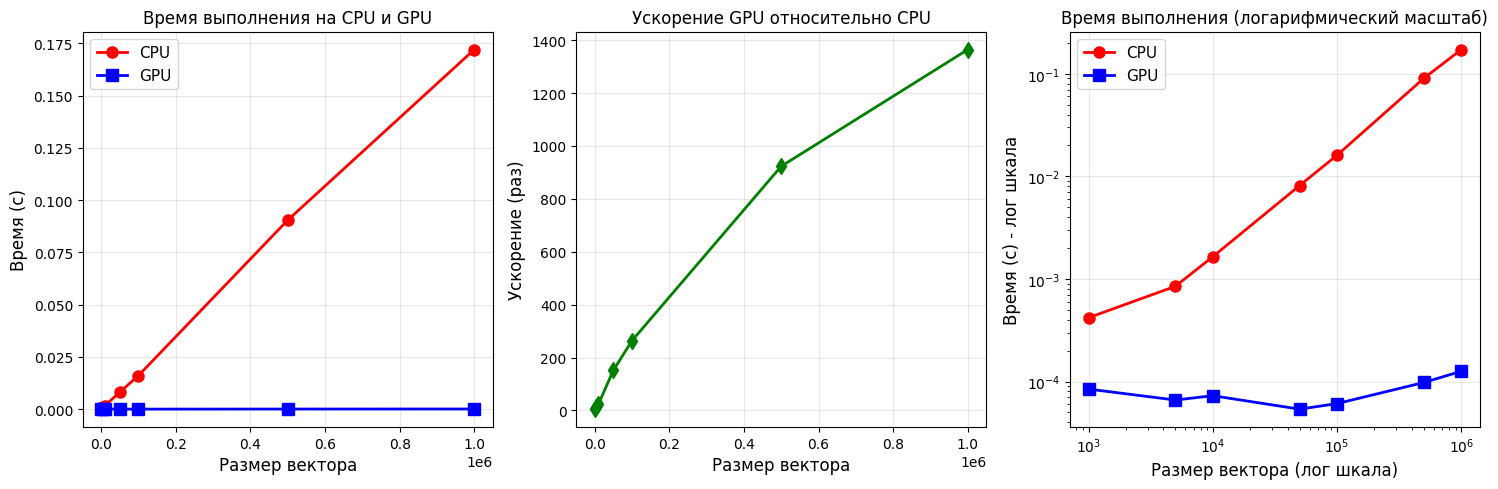


График сохранён как 'vector_sum_results.png'


In [8]:
sizes = [r['Размер'] for r in results]
cpu_times = [r['Время CPU (с)'] for r in results]
gpu_times = [r['Время GPU (с)'] for r in results]
speedups = [r['Ускорение'] for r in results]

plt.figure(figsize=(15, 5))

# График 1: Время выполнения
plt.subplot(1, 3, 1)
plt.plot(sizes, cpu_times, 'o-', label='CPU', color='red', linewidth=2, markersize=8)
plt.plot(sizes, gpu_times, 's-', label='GPU', color='blue', linewidth=2, markersize=8)
plt.xlabel('Размер вектора', fontsize=12)
plt.ylabel('Время (с)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.title('Время выполнения на CPU и GPU', fontsize=12)

# График 2: Ускорение
plt.subplot(1, 3, 2)
plt.plot(sizes, speedups, 'd-', color='green', linewidth=2, markersize=8)
plt.xlabel('Размер вектора', fontsize=12)
plt.ylabel('Ускорение (раз)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.title('Ускорение GPU относительно CPU', fontsize=12)

# График 3: Логарифмический масштаб
plt.subplot(1, 3, 3)
plt.loglog(sizes, cpu_times, 'o-', label='CPU', color='red', linewidth=2, markersize=8)
plt.loglog(sizes, gpu_times, 's-', label='GPU', color='blue', linewidth=2, markersize=8)
plt.xlabel('Размер вектора (лог шкала)', fontsize=12)
plt.ylabel('Время (с) - лог шкала', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.title('Время выполнения (логарифмический масштаб)', fontsize=12)

plt.tight_layout()
plt.savefig('vector_sum_results.png', dpi=150)
plt.show()

print("\nГрафик сохранён как 'vector_sum_results.png'")